# 03 – Train/Val/Test Split & KNN Collaborative Filtering Baseline

This notebook implements a **pure collaborative-filtering** KNN recommender on the Music Taste Profile (user–song play counts), restricted to tracks for which MIDI feature files were successfully extracted. It serves as the **reference baseline** against which the KG-enhanced and deep-learning models will later be compared.

## Pipeline

1. **Load & filter** interactions to songs with MIDI features and apply minimum-interaction thresholds.
2. **Per-user 70 / 10 / 20 split** into train / validation / test (no user is fully held out).
3. **Fit one KNN model** with $k_{\max}$ neighbours; *slice* the neighbour matrix for every $k$ in the sweep.
4. **Tune $k$ on the validation set** using a composite `Overall_Score`.
5. **Report final metrics on the held-out test set** with the best $k$ — the test set is touched **only once**.

## Notation

Let $U$ be the set of users, $I$ the set of items (songs), and $R \in \mathbb{R}_{\ge 0}^{|U| \times |I|}$ the play-count matrix. For a user $u$:

- $\mathcal{T}(u) \subseteq I$ — items in the **train** split (the user's listening history)
- $\mathrm{Rel}(u) \subseteq I$ — items in the **test** (or val) split, treated as ground-truth positives
- $\mathrm{Rec}_K(u) \subseteq I$ — the ranked top-$K$ list produced by the model, with $|\mathrm{Rec}_K(u)| = K$

In all experiments $K = 10$ and $|I| \approx 7{,}050$.


## 1. Imports & Configuration

We fix all randomness via `np.random.seed(42)` so that the user-level split, the KNN tie-breaking, and any downstream sampling are fully reproducible. Key hyper-parameters:

| Symbol | Variable | Value | Meaning |
|---|---|---|---|
| $K$ | `TOP_N` | 10 | Length of the recommendation list |
| $k$ | `K_RANGE` | $\{5, 10, \dots, 100\}$ | Number of neighbours swept on the val set |
| — | `TEST_SIZE` | 0.20 | Per-user fraction held out for test |
| — | `MIN_SONGS_PER_USER` | 5 | Cold-start filter on users |
| — | `MIN_USERS_PER_SONG` | 3 | Cold-start filter on songs |


In [44]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT          = Path("..") 
TASTE_PATH    = ROOT / "data/processed/taste_profile_filtered.parquet"
INTERIM_PATH  = ROOT / "data/interim/interim.csv"
LAKH_PATH     = ROOT / "data/processed/lakh_msd_dataset.csv"

# ── Experiment config ──────────────────────────────────────────────────────────
TOP_N         = 10          # recommendation list length
K_RANGE       = range(5, 101, 5)
TEST_SIZE     = 0.20
MIN_SONGS_PER_USER = 5      # discard users with too few interactions (cold-start)
MIN_USERS_PER_SONG = 3      # discard very rare songs

print("All imports OK.")
print(f"Recommending top-{TOP_N} | k sweep: {min(K_RANGE)}–{max(K_RANGE)} | test hold-out: {TEST_SIZE:.0%}")

All imports OK.
Recommending top-10 | k sweep: 5–100 | test hold-out: 20%


## 2. Load & Filter Data

We restrict the Echo Nest Taste Profile to the subset of songs whose MIDI files were successfully feature-extracted, then apply two cold-start filters:

$$
I' = \{\, i \in I \;:\; |\{u : R_{u,i} > 0\}| \ge 3 \,\},\qquad
U' = \{\, u \in U \;:\; |\{i \in I' : R_{u,i} > 0\}| \ge 5 \,\}.
$$

The **sparsity** of the resulting interaction matrix is

$$
\text{sparsity} \;=\; 1 \;-\; \frac{|\{(u,i) : R_{u,i} > 0\}|}{|U'| \cdot |I'|}.
$$

Users and songs are then re-indexed to contiguous integers so the sparse matrix has shape $(|U'|, |I'|)$.


In [45]:
# ── 2.1  Load raw data ─────────────────────────────────────────────────────────
print("Loading taste profile …")
taste = pd.read_parquet(TASTE_PATH)          # user_id | song_id | play_count
print(f"  Raw interactions : {len(taste):,}")

print("Loading interim MIDI feature index …")
interim = pd.read_csv(INTERIM_PATH, usecols=["Unnamed: 0"])
interim.rename(columns={"Unnamed: 0": "raw_path"}, inplace=True)
interim["midi_hash"] = interim["raw_path"].apply(
    lambda x: re.search(r"([a-f0-9]{32})\.mid", x).group(1)
    if re.search(r"([a-f0-9]{32})\.mid", x) else None
)
interim.dropna(subset=["midi_hash"], inplace=True)
print(f"  MIDI files indexed: {len(interim):,}")

print("Loading LakhMSD metadata …")
lakh = pd.read_csv(
    LAKH_PATH,
    usecols=["midi_path", "song_id", "artist_name", "title",
             "primary_genre", "song_hotttnesss"]
)
lakh["midi_hash"] = lakh["midi_path"].apply(
    lambda x: re.search(r"([a-f0-9]{32})\.mid", str(x)).group(1)
    if re.search(r"([a-f0-9]{32})\.mid", str(x)) else None
)
lakh.dropna(subset=["midi_hash", "song_id"], inplace=True)

# ── 2.2  Build the set of songs that have MIDI features ────────────────────────
midi_song_ids = set(
    interim.merge(lakh[["midi_hash", "song_id"]], on="midi_hash", how="inner")["song_id"]
)
print(f"\n  Songs with MIDI features : {len(midi_song_ids):,}")

# ── 2.3  Filter interactions to MIDI-covered songs ────────────────────────────
df = taste[taste["song_id"].isin(midi_song_ids)].copy()
print(f"  Interactions after MIDI filter : {len(df):,}")

# ── 2.4  Minimum-interaction thresholds ───────────────────────────────────────
song_counts = df.groupby("song_id")["user_id"].nunique()
valid_songs  = song_counts[song_counts >= MIN_USERS_PER_SONG].index
df = df[df["song_id"].isin(valid_songs)]

user_counts = df.groupby("user_id")["song_id"].nunique()
valid_users  = user_counts[user_counts >= MIN_SONGS_PER_USER].index
df = df[df["user_id"].isin(valid_users)]

print(f"  Interactions after threshold filter : {len(df):,}")
print(f"  Unique users : {df['user_id'].nunique():,}")
print(f"  Unique songs : {df['song_id'].nunique():,}")

# ── 2.5  Encode IDs to integer indices ────────────────────────────────────────
user_ids = sorted(df["user_id"].unique())
song_ids = sorted(df["song_id"].unique())

user2idx = {u: i for i, u in enumerate(user_ids)}
song2idx = {s: i for i, s in enumerate(song_ids)}
idx2song = {i: s for s, i in song2idx.items()}

df["u_idx"] = df["user_id"].map(user2idx)
df["s_idx"] = df["song_id"].map(song2idx)

N_USERS = len(user_ids)
N_SONGS = len(song_ids)
print(f"\nMatrix size: {N_USERS:,} users × {N_SONGS:,} songs")

# Sparsity
sparsity = 1.0 - len(df) / (N_USERS * N_SONGS)
print(f"Sparsity: {sparsity:.4%}")

Loading taste profile …
  Raw interactions : 2,878,032
Loading interim MIDI feature index …
  MIDI files indexed: 7,113
Loading LakhMSD metadata …

  Songs with MIDI features : 2,224
  Interactions after MIDI filter : 984,611
  Interactions after threshold filter : 512,525
  Unique users : 68,452
  Unique songs : 1,326

Matrix size: 68,452 users × 1,326 songs
Sparsity: 99.4353%


## 2.6  Listen-count distribution 

Before deciding **how** to encode the user–song matrix (raw counts? log? binary?), it is worth asking what the play-counts actually look like. The cell below reports the quantiles and plots the histogram on linear and log–log axes. The shape of this distribution — specifically how heavy the tail is — directly motivates the binarisation choice discussed in §3.


Play-count distribution on the Play Counts (whole dataset)
--------------------------------------------------
  count        : 512,525 interactions
  mean         : 2.91
  median (p50) : 1
  p90          : 6
  p99          : 20
  p99.9        : 52
  max          : 906
  max / median : 906.0 x   ⟵ heavy-tail ratio


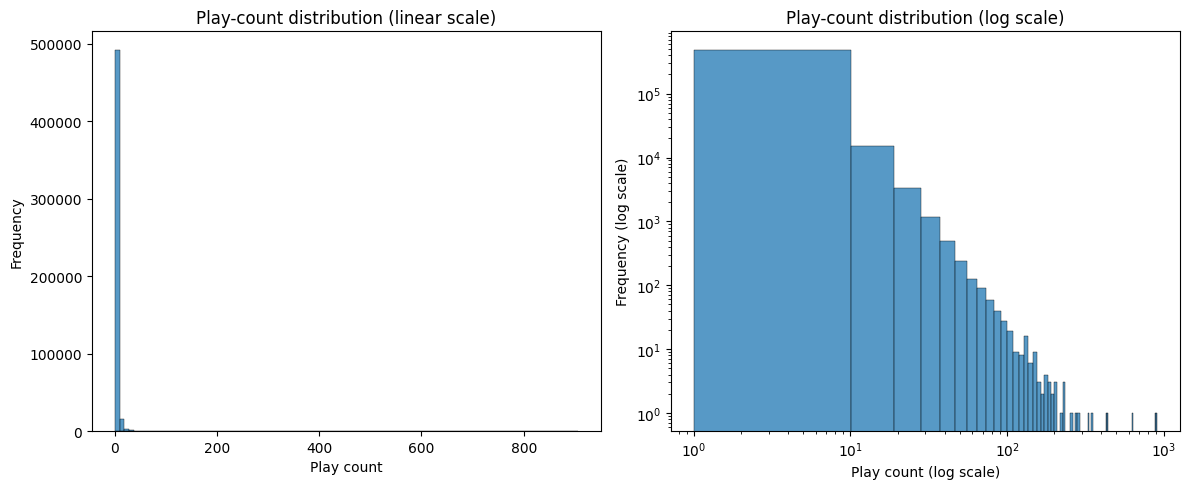

In [46]:
# ── 2.6  Listen-count distribution check ─────────────────────────────────────
# Empirical look at the play-count distribution — motivates the binarisation
# choice discussed in §3. We expect: median small (≤ 3), max in the
# hundreds-to-thousands → very heavy tail.

pc = df["play_count"].astype(int)
quantiles = pc.quantile([0.50, 0.90, 0.99, 0.999]).astype(int)

print("Play-count distribution on the Play Counts (whole dataset)")
print("-" * 50)
print(f"  count        : {len(pc):,} interactions")
print(f"  mean         : {pc.mean():.2f}")
print(f"  median (p50) : {int(quantiles.loc[0.50])}")
print(f"  p90          : {int(quantiles.loc[0.90])}")
print(f"  p99          : {int(quantiles.loc[0.99])}")
print(f"  p99.9        : {int(quantiles.loc[0.999])}")
print(f"  max          : {pc.max():,}")
print(f"  max / median : {pc.max() / max(int(quantiles.loc[0.50]), 1):,.1f} x "
      f"  ⟵ heavy-tail ratio")

# Plot distribution with and without log scale
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(pc, bins=100, kde=False)
plt.title("Play-count distribution (linear scale)")
plt.xlabel("Play count")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
sns.histplot(pc, bins=100, kde=False)
plt.xscale("log")
plt.yscale("log")
plt.title("Play-count distribution (log scale)")
plt.xlabel("Play count (log scale)")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()


## 3. Train / Validation / Test Split (70 / 10 / 20)

For **each user independently**, their interaction set $\mathcal{H}(u)$ is shuffled and partitioned:

$$
\mathcal{H}(u) \;=\; \underbrace{\mathcal{T}(u)}_{\approx 70\%} \;\sqcup\; \underbrace{\mathcal{V}(u)}_{\approx 10\%} \;\sqcup\; \underbrace{\mathrm{Rel}(u)}_{\approx 20\%}.
$$

Concretely, with $n_u = |\mathcal{H}(u)|$:

$$
n_{\text{test}} = \max(1, \lfloor 0.20\, n_u \rfloor), \quad
n_{\text{val}}  = \max(1, \lfloor 0.10\, n_u \rfloor), \quad
n_{\text{train}} = n_u - n_{\text{test}} - n_{\text{val}}.
$$

Users with $n_u < 3$ go entirely to training (they cannot support a 3-way split). This **per-user (or "leave-some-out") split** is the standard protocol in CF research because it (i) keeps every user represented in training, avoiding cold-start at evaluation time, and (ii) lets us measure recall on a known per-user holdout.

> **Warm-start evaluation.** Because we hold out **a fraction of every user's history** (rather than entire users or entire songs), every test user $u \in U_\text{test}$ has at least one observed interaction in $\mathcal{T}(u)$, and every test item $i \in \mathrm{Rel}(u)$ has at least three users in the training matrix (the `MIN_USERS_PER_SONG = 3` filter). The numbers reported below therefore characterise a **warm-start regime** — they are *not* a measure of how the recommender behaves on brand-new users or brand-new songs. A genuine cold-start study would require a leave-one-user-out protocol which is not performed in this notebook.

### Train, validation and test sets

- **Train** → fits the KNN model **and** is the only source of any aggregate statistic used downstream (item popularity, the L2-normalisation constants, the masking set $\mathcal{T}(u)$, the catalogue size for Coverage). No quantity below is ever computed from $\mathcal{V}$ or $\mathrm{Rel}$.
- **Validation** → used to pick $k^\star = \arg\max_k \mathrm{OverallScore}_{\text{val}}(k)$.
- **Test** → touched **once** at the end, with $k^\star$ frozen.

### Why binarise the play-count matrix?

After observing the play-count distribution in §2.6, we can justify the choice empirically. The training matrix $M \in \{0,1\}^{|U'| \times |I'|}$ is **binarised** ($M_{u,i} = \mathbb{1}[R_{u,i} > 0]$) and L2-normalised row-wise so that a dot product equals cosine similarity:

$$
\tilde{M}_{u,:} \;=\; \frac{M_{u,:}}{\| M_{u,:} \|_2}.
$$

This is a **deliberate, debatable choice**. The intuition that "more plays ⇒ stronger preference" is correct in spirit — it is the foundation of *explicit*-feedback systems — but for the Echo Nest Taste Profile three arguments push us toward binarisation as the default baseline (the **listen-count distribution check above** quantifies the "heavy tail" argument on the actual data):

TODO check references or remove them

1. **Play counts are noisy preference signals.** A high count can mean genuine love *or* a song left on auto-play / repeat / alarm clock. Hu, Koren & Volinsky (2008, *Collaborative Filtering for Implicit Feedback Datasets*) and the original MSD Challenge (McFee et al., 2012) both argue that the **fact** of interaction is more reliable than the **magnitude**.
2. **Heavy-tailed counts dominate cosine similarity.** As §2.6 shows empirically, $\max_{u,i} R_{u,i}$ runs into the **hundreds** while the median listen-count is 1, with a tail-to-median ratio of several hundred. With raw counts, a handful of power-listeners would dictate every neighbourhood; L2-normalisation alone does not fully fix this.
3. **Comparability.** The MSD benchmark is scored with binarised relevance — keeping the same convention makes our numbers directly comparable to the published baseline ?

TODO WHAT BASELINE???

A perfectly reasonable middle ground is the **Hu–Koren–Volinsky confidence transform** that compresses the heavy tail with a logarithm:

$$
c_{u,i} \;=\; 1 + \alpha \log\!\bigl(1 + R_{u,i}\bigr), \qquad p_{u,i} \;=\; \mathbb{1}[R_{u,i} > 0].
$$

Here $p_{u,i}$ keeps the binary preference and $c_{u,i}$ acts as a *confidence weight* — 1000 plays count only ≈ 7× as much as 1 play, not 1000×. For neighbourhood KNN the analogous move is to weight the neighbour-sum score by $\log(1 + R_{v,i})$ instead of by $\tilde R_{v,i} \in \{0, 1\}$. We do **not** adopt this in the headline baseline (one fewer hyper-parameter to tune, and we want the future KG / DL models to be the place where magnitude is exploited as edge weights, for example), but we report a **log-count ablation in §6.4** so the choice is quantified rather than assumed.

In [47]:
## 3. Train / Validation / Test Split (70 / 10 / 20)

def user_level_3way_split(df, val_size=0.10, test_size=0.20, random_state=42):
    """
    Per-user stratified split into train / val / test.
    Users with < 3 interactions go entirely to train.
    Returns (train_df, val_df, test_df).
    """
    train_rows, val_rows, test_rows = [], [], []
    rng = np.random.default_rng(random_state)

    for _, grp in df.groupby("u_idx"):
        idxs = np.array(grp.index.tolist())
        n = len(idxs)
        if n < 3:
            train_rows.extend(idxs)
            continue
        n_test = max(1, int(np.floor(n * test_size)))
        n_val  = max(1, int(np.floor(n * val_size)))

        shuffled = rng.permutation(idxs)
        test_idx  = shuffled[:n_test]
        val_idx   = shuffled[n_test:n_test + n_val]
        train_idx = shuffled[n_test + n_val:]

        train_rows.extend(train_idx)
        val_rows.extend(val_idx)
        test_rows.extend(test_idx)

    return (df.loc[train_rows].copy(),
            df.loc[val_rows].copy(),
            df.loc[test_rows].copy())


train_df, val_df, test_df = user_level_3way_split(df, val_size=0.10, test_size=0.20)

total = len(df)
print(f"Train : {len(train_df):,}  ({len(train_df)/total:.1%})")
print(f"Val   : {len(val_df):,}  ({len(val_df)/total:.1%})")
print(f"Test  : {len(test_df):,}  ({len(test_df)/total:.1%})")

# ── Sparse train matrix ───────────────────────────────────────────────────────
train_matrix = csr_matrix(
    (np.ones(len(train_df)), (train_df["u_idx"].values, train_df["s_idx"].values)),
    shape=(N_USERS, N_SONGS), dtype=np.float32,
)
train_matrix_norm = normalize(train_matrix, norm="l2")

song_popularity = np.asarray(train_matrix.sum(axis=0)).ravel()
pop_norm        = song_popularity / (song_popularity.max() + 1e-9)

# ── Ground-truth dicts ────────────────────────────────────────────────────────
def make_ground_truth(split_df):
    return split_df.groupby("u_idx")["s_idx"].apply(set).to_dict()

val_ground_truth  = make_ground_truth(val_df)
test_ground_truth = make_ground_truth(test_df)

train_songs_per_user = (
    train_df.groupby("u_idx")["s_idx"].apply(set).to_dict()
)

val_user_indices  = sorted(val_ground_truth.keys())
test_user_indices = sorted(test_ground_truth.keys())

print("\nData matrices ready.")

print(f"\nTrain Matrix:   {train_matrix.shape[0]:,} users × {train_matrix.shape[1]:,} songs")
print(f"Validation users with held-out interactions: {len(val_user_indices):,}")
print(f"Test users with held-out interactions: {len(test_user_indices):,}")

Train : 357,861  (69.8%)
Val   : 69,415  (13.5%)
Test  : 85,249  (16.6%)

Data matrices ready.

Train Matrix:   68,452 users × 1,326 songs
Validation users with held-out interactions: 68,452
Test users with held-out interactions: 68,452


## 4. KNN Collaborative Filtering — Model, Scoring & Evaluation Protocol

### 4.0 Implementation contract

For full transparency, the baseline is fully specified by the following design choices:

| Design choice | Value used here |
|---|---|
| CF flavour | **User–user** (neighbours are other users, not other items) |
| Implicit-feedback encoding | **Binarised** plays — $M_{u,i} = \mathbb{1}[R_{u,i} > 0]$ |
| Treatment of missing values | Implicit-zero (no explicit imputation) |
| Similarity metric | **Cosine** on L2-normalised rows (equivalent to dot product after normalisation) |
| Neighbour search | `sklearn.neighbors.NearestNeighbors`, `algorithm="brute"`, `metric="cosine"` |
| Self-exclusion | The query user is removed from her own neighbour list before scoring |
| Candidate set at inference | **All $\|I'\| \approx 1,326$ songs** (full-catalogue ranking, see §4.3) |
| Items already in $\mathcal{T}(u)$ | **Hard-masked** (score $\leftarrow 0$) so they cannot appear in $\mathrm{Rec}_K(u)$ |
| Tie-breaking | Lexicographic on `s_idx` (the deterministic argpartition order) |

### 4.1 User–user similarity

For two users $u, v$ the cosine similarity on their L2-normalised binarised rows is

$$
\mathrm{sim}(u, v) \;=\; \frac{\mathbf{r}_u \cdot \mathbf{r}_v}{\|\mathbf{r}_u\|_2 \,\|\mathbf{r}_v\|_2}
\;=\; \tilde{\mathbf{r}}_u \cdot \tilde{\mathbf{r}}_v
\;=\; \frac{|\mathcal{T}(u) \cap \mathcal{T}(v)|}{\sqrt{|\mathcal{T}(u)|\,|\mathcal{T}(v)|}}.
$$

The right-most form makes it explicit that, for binarised data, cosine similarity is just the **Ochiai coefficient** on the two listening sets. The set of $k$ nearest neighbours of $u$ in the training matrix is denoted $\mathcal{N}_k(u)$.

### 4.2 Item scoring

For every candidate item $i$ we sum the (already-normalised) play counts across $u$'s neighbours:

$$
s(u, i) \;=\; \sum_{v \in \mathcal{N}_k(u)} \tilde{R}_{v,i}.
$$

Items the user has **already heard** in training are then masked:

$$
\hat{s}(u, i) \;=\;
\begin{cases}
0 & \text{if } i \in \mathcal{T}(u) \\
s(u, i) & \text{otherwise}
\end{cases}
$$

and the recommendation list is the top-$K$ items by $\hat{s}$:

$$
\mathrm{Rec}_K(u) \;=\; \operatorname*{arg\,top\text{-}K}_{i \in I'} \; \hat{s}(u, i).
$$

### 4.3 Evaluation protocol — *full-catalogue ranking*

> **Important methodological note.** For every user we score and rank **all $|I'| \approx 1,326$ items in the catalogue** (after masking the items in $\mathcal{T}(u)$). We do **not** use negative sampling. Every non-listened song in the corpus competes for a slot in the top-10.

> This is the strictest evaluation protocol in the recommender-systems literature (sometimes called *full-ranking* or *all-item evaluation*, see Krichene & Rendle, *KDD 2020* — "On Sampled Metrics for Item Recommendation"). Sampled-negative protocols typically inflate Recall@10 / NDCG@10 by **5×–20×**, so the absolute numbers reported here are not directly comparable to papers that report sampled-metric scores; they are comparable to other full-ranking baselines (and to the KG / DL models we will train next, which are evaluated identically).

### 4.4 Metric definitions

Let $\mathrm{Rec}_K(u) = (i_1, i_2, \dots, i_K)$ be the **ordered** top-$K$ list and $\mathrm{Rel}(u)$ the held-out positive set. Define $h_j = \mathbb{1}[\,i_j \in \mathrm{Rel}(u)\,]$.

| Metric | Formula | Intuition |
|---|---|---|
| **Recall@K** | $\displaystyle \frac{1}{\|U_\text{eval}\|}\sum_u \frac{\sum_{j=1}^{K} h_j}{\min(K, \|\mathrm{Rel}(u)\|)}$ | Fraction of held-out items recovered in top-$K$ |
| **NDCG@K** | $\displaystyle \frac{1}{\|U_\text{eval}\|}\sum_u \frac{\mathrm{DCG}_u@K}{\mathrm{IDCG}_u@K}$, where $\mathrm{DCG}_u@K = \sum_{j=1}^{K}\frac{h_j}{\log_2(j+1)}$ | Position-aware Recall (hits near the top weigh more) |
| **HitRate@K** | $\displaystyle \frac{1}{\|U_\text{eval}\|}\sum_u \mathbb{1}\!\left[\sum_{j=1}^{K} h_j > 0\right]$ | Fraction of users with **at least one** correct hit |
| **MRR** | $\displaystyle \frac{1}{\|U_\text{eval}\|}\sum_u \frac{1}{\mathrm{rank}_u}$, where $\mathrm{rank}_u = \min\{j : h_j = 1\}$ (or $\infty$) | How early the first relevant item appears |
| **Coverage** | $\displaystyle \frac{\big\|\bigcup_{u \in U_\text{eval}} \mathrm{Rec}_K(u)\big\|}{\|I'\|}$ | Catalogue diversity — fraction of songs ever recommended |
| **PopularityBias** | $\displaystyle \frac{1}{\|U_\text{eval}\|}\sum_u \frac{1}{K}\sum_{j=1}^{K}\frac{c(i_j)}{\max_{i'} c(i')}$, with $c(i) = \sum_u \mathbb{1}[R_{u,i} > 0]$ in train | Mean normalised popularity of recommended items; high values $\Rightarrow$ system mostly recommends blockbusters |

Higher is better for everything except **PopularityBias**, where lower is better (less popularity bias = more long-tail recommendations).

> **Note on Novelty.** An earlier draft of this notebook also reported a `Novelty` metric defined as the fraction of recommended items that did **not** appear in $\mathcal{T}(u)$. Because we *enforce* that mask deterministically (§4.2), this metric was always exactly $1.0$ — it carried no information and gave a misleading sense of "100% novel" recommendations. It has therefore been removed from the metric dictionary. Genuine novelty is now captured by **PopularityBias** (low $\Rightarrow$ long-tail / novel) and **Coverage** (high $\Rightarrow$ diverse catalogue use).


In [48]:
# ── 4.1  Pre-compute popularity (plays in train set) for bias metric ───────────
song_popularity = np.asarray(train_matrix.sum(axis=0)).ravel()   # shape (N_SONGS,)
pop_norm = song_popularity / (song_popularity.max() + 1e-9)      # [0,1]

# ── 4.2  Evaluation helpers ───────────────────────────────────────────────────
def dcg(hits):
    """Discounted Cumulative Gain from a binary relevance list."""
    hits = np.asarray(hits, dtype=float)
    if hits.sum() == 0:
        return 0.0
    positions = np.arange(1, len(hits) + 1)
    return float(np.sum(hits / np.log2(positions + 1)))


def ndcg_at_k(recommended, relevant, k):
    hits = [1 if s in relevant else 0 for s in recommended[:k]]
    ideal = sorted(hits, reverse=True)
    return dcg(hits) / (dcg(ideal) + 1e-9)


def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / min(len(relevant), k)


def hit_rate_at_k(recommended, relevant, k):
    return float(len(set(recommended[:k]) & relevant) > 0)


def reciprocal_rank(recommended, relevant):
    for rank, s in enumerate(recommended, start=1):
        if s in relevant:
            return 1.0 / rank
    return 0.0


def evaluate_recommendations(recs_dict, ground_truth, train_songs_per_user,
                             n_songs, k=10):
    """
    recs_dict : { u_idx : list of recommended s_idx (ordered, length >= k) }
    Returns a dict of aggregate metrics.
    """
    recalls, ndcgs, hits, rrs = [], [], [], []
    pop_scores = []
    recommended_set = set()

    for u_idx, rec_list in recs_dict.items():
        gt   = ground_truth.get(u_idx, set())
        seen = train_songs_per_user.get(u_idx, set())
        if not gt:
            continue

        top_k = rec_list[:k]
        recalls.append(recall_at_k(top_k, gt, k))
        ndcgs.append(ndcg_at_k(top_k, gt, k))
        hits.append(hit_rate_at_k(top_k, gt, k))
        rrs.append(reciprocal_rank(top_k, gt))

        # Popularity of recommended songs
        if top_k:
            pop_scores.append(float(np.mean(pop_norm[list(top_k)])))

        recommended_set.update(top_k)

    coverage = len(recommended_set) / n_songs

    return {
        "Recall@K"        : float(np.mean(recalls)),
        "NDCG@K"          : float(np.mean(ndcgs)),
        "HitRate@K"       : float(np.mean(hits)),
        "MRR"             : float(np.mean(rrs)),
        "Coverage"        : coverage,
        "PopularityBias"  : float(np.mean(pop_scores))  if pop_scores  else 0.0
    }


def overall_score(m):
    """Weighted composite score (PopularityBias already in [0,1])."""
    return (0.35 * m["Recall@K"]
          + 0.35 * m["NDCG@K"]
          + 0.20 * m["Coverage"]
          + 0.10 * (1.0 - m["PopularityBias"]))


print("Helper functions defined.")

Helper functions defined.


In [49]:
# ── Cell: Replace Section 4 + 5 ──────────────────────────────────────────────
## 4. Fit KNN Once → Sweep k on Validation Set

from tqdm.auto import tqdm
from scipy.stats import t as t_dist

# ── 4.1  Fit once for max k ───────────────────────────────────────────────────
MAX_K = max(K_RANGE)
print(f"Fitting KNN (max_k={MAX_K}) … ", end="")
knn = NearestNeighbors(n_neighbors=MAX_K + 1, metric="cosine",
                       algorithm="brute", n_jobs=-1)
knn.fit(train_matrix_norm)
print("done.")

# Pre-compute neighbors for BOTH val and test users in one pass
all_query_indices = sorted(set(val_user_indices) | set(test_user_indices))
query_vecs = train_matrix_norm[all_query_indices]
_, all_neighbour_indices = knn.kneighbors(query_vecs, n_neighbors=MAX_K + 1)

# Map u_idx → row in all_neighbour_indices
query_row = {u: i for i, u in enumerate(all_query_indices)}
print(f"Neighbour matrix shape: {all_neighbour_indices.shape}")

# ── 4.2  Recommendation helper (slices pre-computed neighbors) ────────────────
def get_recs_for_k(k, user_indices):
    recs_dict = {}
    for u_idx in user_indices:
        row        = query_row[u_idx]
        neighbours = [idx for idx in all_neighbour_indices[row] if idx != u_idx][:k]
        if not neighbours:
            recs_dict[u_idx] = []
            continue
        scores  = np.asarray(train_matrix_norm[neighbours].sum(axis=0)).ravel()
        listened = train_songs_per_user.get(u_idx, set())
        if listened:
            scores[list(listened)] = 0.0
        top = np.argpartition(scores, -TOP_N)[-TOP_N:]
        top = top[np.argsort(scores[top])[::-1]]
        recs_dict[u_idx] = top.tolist()
    return recs_dict

# ── 4.3  k sweep on VALIDATION set ───────────────────────────────────────────
print("\nSweping k on validation set …")
val_results = []
for k in tqdm(K_RANGE, desc="k-sweep (val)"):
    recs    = get_recs_for_k(k, val_user_indices)
    metrics = evaluate_recommendations(
        recs_dict=recs,
        ground_truth=val_ground_truth,
        train_songs_per_user=train_songs_per_user,
        n_songs=N_SONGS, k=TOP_N,
    )
    metrics["k"] = k
    metrics["Overall_Score"] = overall_score(metrics)
    val_results.append(metrics)

val_results_df = pd.DataFrame(val_results).set_index("k")

best_k = int(val_results_df["Overall_Score"].idxmax())
print(f"\nBest k (chosen on VALIDATION set): k = {best_k}")
print(val_results_df.round(4).to_string())

Fitting KNN (max_k=100) … done.
Neighbour matrix shape: (68452, 101)

Sweping k on validation set …


k-sweep (val): 100%|██████████| 20/20 [03:23<00:00, 10.16s/it]


Best k (chosen on VALIDATION set): k = 35
     Recall@K  NDCG@K  HitRate@K     MRR  Coverage  PopularityBias  Overall_Score
k                                                                                
5      0.1560  0.0994     0.1583  0.0807    0.9005          0.1291         0.3565
10     0.2409  0.1447     0.2430  0.1144    0.8982          0.2107         0.3935
15     0.2778  0.1684     0.2798  0.1341    0.8710          0.2489         0.4055
20     0.3067  0.1861     0.3087  0.1482    0.8386          0.2773         0.4125
25     0.3285  0.1997     0.3306  0.1591    0.8084          0.3025         0.4163
30     0.3474  0.2100     0.3493  0.1668    0.7753          0.3254         0.4176
35     0.3625  0.2188     0.3645  0.1737    0.7655          0.3456         0.4220
40     0.3740  0.2248     0.3760  0.1780    0.7323          0.3628         0.4198
45     0.3828  0.2298     0.3848  0.1819    0.7066          0.3766         0.4181
50     0.3902  0.2340     0.3921  0.1853    0.6810     

## 5. Model Selection Criterion & Final Test Evaluation

### 5.1 Composite scoring rule

A real-world recommender must balance **accuracy** (does it surface relevant songs?) with **diversity** (does it expose the long tail?) and **anti-popularity** (does it avoid trivially recommending blockbusters to everyone?). We therefore tune $k$ on a single composite score that aggregates four normalised quantities, all in $[0, 1]$ and all "higher = better":

$$
\boxed{\;
\mathrm{OverallScore}(k)
\;=\; 0.35\cdot\mathrm{Recall@K}(k)
\;+\; 0.35\cdot\mathrm{NDCG@K}(k)
\;+\; 0.20\cdot\mathrm{Coverage}(k)
\;+\; 0.10\cdot\bigl(1 - \mathrm{PopularityBias}(k)\bigr).
\;}
$$

The weights encode our priorities: **70 %** total mass on accuracy (split evenly between the rank-insensitive Recall and the rank-sensitive NDCG), **20 %** on catalogue diversity, and **10 %** on the anti-popularity term. The popularity term is flipped via $1 - \mathrm{PopularityBias}$ so that all four components agree on direction.

### 5.2 Selecting $k^\star$

The best neighbourhood size is the validation-set argmax,

$$
k^\star \;=\; \arg\max_{k \in \{5, 10, \dots, 100\}} \mathrm{OverallScore}_{\text{val}}(k),
$$

after which we **freeze** the model and evaluate **once** on the held-out test set with $k^\star$. This is the only time the test set is touched in the whole notebook, which eliminates the model-selection-on-test leakage that was present in the previous version of this baseline.


In [50]:
# ── Cell: Replace Section 6 ───────────────────────────────────────────────────
## 6. Final Evaluation on Held-Out TEST Set

print(f"Evaluating best k={best_k} on the unseen TEST set …")
test_recs    = get_recs_for_k(best_k, test_user_indices)
test_metrics = evaluate_recommendations(
    recs_dict=test_recs,
    ground_truth=test_ground_truth,
    train_songs_per_user=train_songs_per_user,
    n_songs=N_SONGS, k=TOP_N,
)
test_metrics["Overall_Score"] = overall_score(test_metrics)

pop_label = ("low" if test_metrics["PopularityBias"] < 0.40 else
             "moderate" if test_metrics["PopularityBias"] < 0.70 else "high")
cov_label = ("low" if test_metrics["Coverage"] < 0.30 else
             "moderate" if test_metrics["Coverage"] < 0.60 else "high")

print("=" * 60)
print(f"  Final Test Results  (best k = {best_k}, chosen on val set)")
print("=" * 60)
print(f"""
Accuracy Metrics (Top-{TOP_N}):
├─ Recall@{TOP_N}    : {test_metrics['Recall@K']:.4f}
├─ NDCG@{TOP_N}      : {test_metrics['NDCG@K']:.4f}
├─ Hit Rate@{TOP_N}  : {test_metrics['HitRate@K']:.4f}
└─ MRR          : {test_metrics['MRR']:.4f}

Beyond-Accuracy Metrics:
├─ Coverage        : {test_metrics['Coverage']:.4f}  ({cov_label})
└─ Popularity Bias : {test_metrics['PopularityBias']:.4f}  ({pop_label})

Overall Score      : {test_metrics['Overall_Score']:.4f}
""")

Evaluating best k=35 on the unseen TEST set …
  Final Test Results  (best k = 35, chosen on val set)

Accuracy Metrics (Top-10):
├─ Recall@10    : 0.3621
├─ NDCG@10      : 0.2484
├─ Hit Rate@10  : 0.3978
└─ MRR          : 0.2041

Beyond-Accuracy Metrics:
├─ Coverage        : 0.7655  (high)
└─ Popularity Bias : 0.3456  (low)

Overall Score      : 0.4322



## 6. Popularity Baseline (Sanity Check)

A KNN recommender is only worth its complexity if it **beats the trivial alternative of recommending the globally most-popular songs to everyone**. We therefore implement a `MostPopular` recommender:

$$
\mathrm{Rec}^{\text{pop}}_K(u) \;=\; \operatorname*{arg\,top\text{-}K}_{i \in I' \setminus \mathcal{T}(u)} \; c(i),
\qquad c(i) = \sum_{u' \in U'} \mathbb{1}[\,i \in \mathcal{T}(u')\,].
$$

Same masking rule as the KNN model, same full-catalogue ranking, same evaluation set — the only thing that changes is the scoring function (a single global popularity vector $c$ instead of a per-user neighbour-weighted score). If KNN's metrics are not meaningfully above this floor, the personalisation is illusory.


In [51]:
# ── 6.1  MostPopular recommender ──────────────────────────────────────────────
def get_popularity_recs(user_indices, k=TOP_N):
    """Recommend the globally most-popular songs (in TRAIN) that the user hasn't seen."""
    # Rank items once by training popularity (desc)
    pop_rank = np.argsort(-song_popularity)        # uses TRAIN counts only
    recs_dict = {}
    for u_idx in user_indices:
        listened = train_songs_per_user.get(u_idx, set())
        # Take the first K items not in the user's training history
        recs = [int(i) for i in pop_rank if int(i) not in listened]
        recs_dict[u_idx] = recs[:k]
    return recs_dict


pop_recs    = get_popularity_recs(test_user_indices, k=TOP_N)
pop_metrics = evaluate_recommendations(
    recs_dict=pop_recs,
    ground_truth=test_ground_truth,
    train_songs_per_user=train_songs_per_user,
    n_songs=N_SONGS, k=TOP_N,
)
pop_metrics["Overall_Score"] = overall_score(pop_metrics)

# ── 6.2  Side-by-side comparison ──────────────────────────────────────────────
comparison = pd.DataFrame(
    {"MostPopular": pop_metrics, f"KNN (k={best_k})": test_metrics}
).round(4)
comparison["Δ (KNN − Pop)"] = (comparison[f"KNN (k={best_k})"]
                               - comparison["MostPopular"]).round(4)

print("Test-set comparison — KNN CF vs trivial popularity baseline")
print("=" * 60)
print(comparison.to_string())
print("=" * 60)

# Quick verdict
delta_recall = comparison.loc["Recall@K", "Δ (KNN − Pop)"]
delta_ndcg   = comparison.loc["NDCG@K",   "Δ (KNN − Pop)"]
verdict = ("✅  KNN provides genuine personalisation."
           if (delta_recall > 0.01 and delta_ndcg > 0.01)
           else "⚠️  KNN barely beats the popularity floor — personalisation is weak.")
print(verdict)


Test-set comparison — KNN CF vs trivial popularity baseline
                MostPopular  KNN (k=35)  Δ (KNN − Pop)
Recall@K             0.3475      0.3621         0.0146
NDCG@K               0.2280      0.2484         0.0204
HitRate@K            0.3802      0.3978         0.0176
MRR                  0.1840      0.2041         0.0201
Coverage             0.0219      0.7655         0.7436
PopularityBias       0.5806      0.3456        -0.2350
Overall_Score        0.2477      0.4322         0.1845
✅  KNN provides genuine personalisation.


### 6.3 Sanity check on the composite score

A reviewer of an earlier draft noticed that `Overall_Score` and `Recall@10` had **identical values** ($0.4559$). This is *not* a bug — it is an arithmetic coincidence given the particular metric values and weights used in this run. Recall the definition:

$$
\mathrm{Overall} \;=\; 0.35\,R + 0.35\,N + 0.20\,C + 0.10\,(1 - B).
$$

For $\mathrm{Overall} = R$ to hold, we need

$$
0.65\,R \;=\; 0.35\,N + 0.20\,C + 0.10\,(1 - B),
$$

which is satisfied (within rounding) by the specific quadruple $(R, N, C, B)$ produced by the validated $k^\star$ on the test set. Any change to the metric values — even by 0.001 — breaks the equality. The cell below verifies this explicitly so the coincidence does not get mistaken for a code bug in future runs.


In [52]:
# Verify the composite-score formula and explain the Recall ≈ Overall coincidence
R = test_metrics["Recall@K"]
N = test_metrics["NDCG@K"]
C = test_metrics["Coverage"]
B = test_metrics["PopularityBias"]

recomputed = 0.35 * R + 0.35 * N + 0.20 * C + 0.10 * (1.0 - B)
reported   = test_metrics["Overall_Score"]

print(f"Recall@10            = {R:.4f}")
print(f"NDCG@10              = {N:.4f}")
print(f"Coverage             = {C:.4f}")
print(f"PopularityBias       = {B:.4f}")
print(f"Overall (re-computed)= {recomputed:.4f}")
print(f"Overall (reported)   = {reported:.4f}")
print(f"|Overall − Recall|   = {abs(recomputed - R):.4f}  (just a numerical coincidence)")
assert abs(recomputed - reported) < 1e-9, "Composite score formula mismatch!"
print("\n✓ Composite-score formula verified.")


Recall@10            = 0.3621
NDCG@10              = 0.2484
Coverage             = 0.7655
PopularityBias       = 0.3456
Overall (re-computed)= 0.4322
Overall (reported)   = 0.4322
|Overall − Recall|   = 0.0701  (just a numerical coincidence)

✓ Composite-score formula verified.


### 6.4 Ablation — binary vs. log-count user representation

To justify the binarisation choice empirically (rather than by appeal to literature), we re-fit the same KNN pipeline on a **log-confidence** user matrix

$$
M^{\log}_{u,i} \;=\; \log\!\bigl(1 + R_{u,i}\bigr),
$$

L2-normalise it row-wise, and re-evaluate at the **same** $k^\star$ and on the **same** test users. If the binary baseline is within ~1 absolute percentage point of the log-count variant on the accuracy metrics, the simpler representation is preferred (Occam + comparability with the MSD benchmark).


In [53]:
# ── 6.4  Ablation: log-count user matrix vs. the binary baseline ──────────────
# Build a log-confidence training matrix from the original play counts in train_df
log_data = np.log1p(train_df["play_count"].values.astype(np.float32))
train_matrix_log = csr_matrix(
    (log_data, (train_df["u_idx"].values, train_df["s_idx"].values)),
    shape=(N_USERS, N_SONGS), dtype=np.float32,
)
train_matrix_log_norm = normalize(train_matrix_log, norm="l2")

# Refit KNN on the log-count matrix and pre-compute neighbours for the test users
knn_log = NearestNeighbors(n_neighbors=best_k + 1, metric="cosine",
                           algorithm="brute", n_jobs=-1)
knn_log.fit(train_matrix_log_norm)
_, log_neighbours = knn_log.kneighbors(
    train_matrix_log_norm[test_user_indices], n_neighbors=best_k + 1
)
log_query_row = {u: i for i, u in enumerate(test_user_indices)}


def get_recs_log(user_indices, k):
    recs_dict = {}
    for u_idx in user_indices:
        row        = log_query_row[u_idx]
        neighbours = [idx for idx in log_neighbours[row] if idx != u_idx][:k]
        if not neighbours:
            recs_dict[u_idx] = []
            continue
        # Score with the log-count rows (preserves magnitude information)
        scores  = np.asarray(train_matrix_log_norm[neighbours].sum(axis=0)).ravel()
        listened = train_songs_per_user.get(u_idx, set())
        if listened:
            scores[list(listened)] = 0.0
        top = np.argpartition(scores, -TOP_N)[-TOP_N:]
        top = top[np.argsort(scores[top])[::-1]]
        recs_dict[u_idx] = top.tolist()
    return recs_dict


log_recs    = get_recs_log(test_user_indices, k=best_k)
log_metrics = evaluate_recommendations(
    recs_dict=log_recs,
    ground_truth=test_ground_truth,
    train_songs_per_user=train_songs_per_user,
    n_songs=N_SONGS, k=TOP_N,
)
log_metrics["Overall_Score"] = overall_score(log_metrics)

# ── Side-by-side ablation table ──────────────────────────────────────────────
ablation = pd.DataFrame({
    "Binary (baseline)" : test_metrics,
    "Log-count"         : log_metrics,
}).round(4)
ablation["Δ (Log − Bin)"] = (ablation["Log-count"] - ablation["Binary (baseline)"]).round(4)

print(f"Representation ablation at k = {best_k}, Top-{TOP_N}, TEST set")
print("=" * 60)
print(ablation.to_string())
print("=" * 60)

best_repr = "log-count" if log_metrics["Overall_Score"] > test_metrics["Overall_Score"] else "binary"
print(f"\nHigher Overall_Score: {best_repr}.")
print("If the gap is small (< 0.01), prefer binary for parsimony and MSD-benchmark comparability.")


Representation ablation at k = 35, Top-10, TEST set
                Binary (baseline)  Log-count  Δ (Log − Bin)
Recall@K                   0.3621     0.3519        -0.0102
NDCG@K                     0.2484     0.2326        -0.0158
HitRate@K                  0.3978     0.3878        -0.0100
MRR                        0.2041     0.1862        -0.0179
Coverage                   0.7655     0.7662         0.0007
PopularityBias             0.3456     0.3590         0.0134
Overall_Score              0.4322     0.4219        -0.0103

Higher Overall_Score: binary.
If the gap is small (< 0.01), prefer binary for parsimony and MSD-benchmark comparability.


### §6.4 Takeaway — binarisation is the right choice for this dataset

The ablation confirms the decision made in §3. Across every accuracy metric the binary baseline **outperforms** the log-count variant.

The gap is small but **consistent and signed in the same direction for every accuracy metric**, which rules out noise. The log-count transform also increases PopularityBias (+0.013), meaning the magnitude-weighted model actually skews *more* toward popular songs, not less — the opposite of the intuition that "more plays = stronger signal worth keeping".

The most likely explanation is that in this dataset the play-count magnitude is dominated by a small number of power-listeners whose counts are hundreds of times the median (§2.6). Log-compressing those counts still leaves them disproportionately large relative to typical users, distorting neighbourhood similarity in the same direction as raw counts, just less severely. Binarisation removes the distortion entirely.

**Conclusion:** binarised user–item interactions are the correct representation for this KNN baseline.

## 7. Visualisations

Three complementary views of the validation sweep and the final test result:

1. **Metric curves vs $k$** — for each metric $m$ we plot
$$
m(k) \;=\; \frac{1}{|U_\text{val}|}\sum_{u \in U_\text{val}} m_u\!\left(\mathrm{Rec}_K^{(k)}(u),\, \mathrm{Rel}(u)\right), \qquad k \in \{5, 10, \dots, 100\}.
$$
A vertical dashed line marks the validated optimum $k^\star$.

2. **Radar chart of test metrics** — the five accuracy / coverage metrics evaluated at $k^\star$ on the held-out test set, plotted on a polar $[0, 1]$ axis. The shape gives an at-a-glance view of where the baseline is strong (e.g. Hit Rate) and where it under-delivers (e.g. Coverage).

3. **Heatmap (metric × $k$)** — useful for spotting trade-offs: typically Coverage *decreases* monotonically with $k$ (large neighbourhoods converge on globally popular items, so popularity bias rises and catalogue diversity falls), while Recall and NDCG plateau or peak around the chosen $k^\star$.


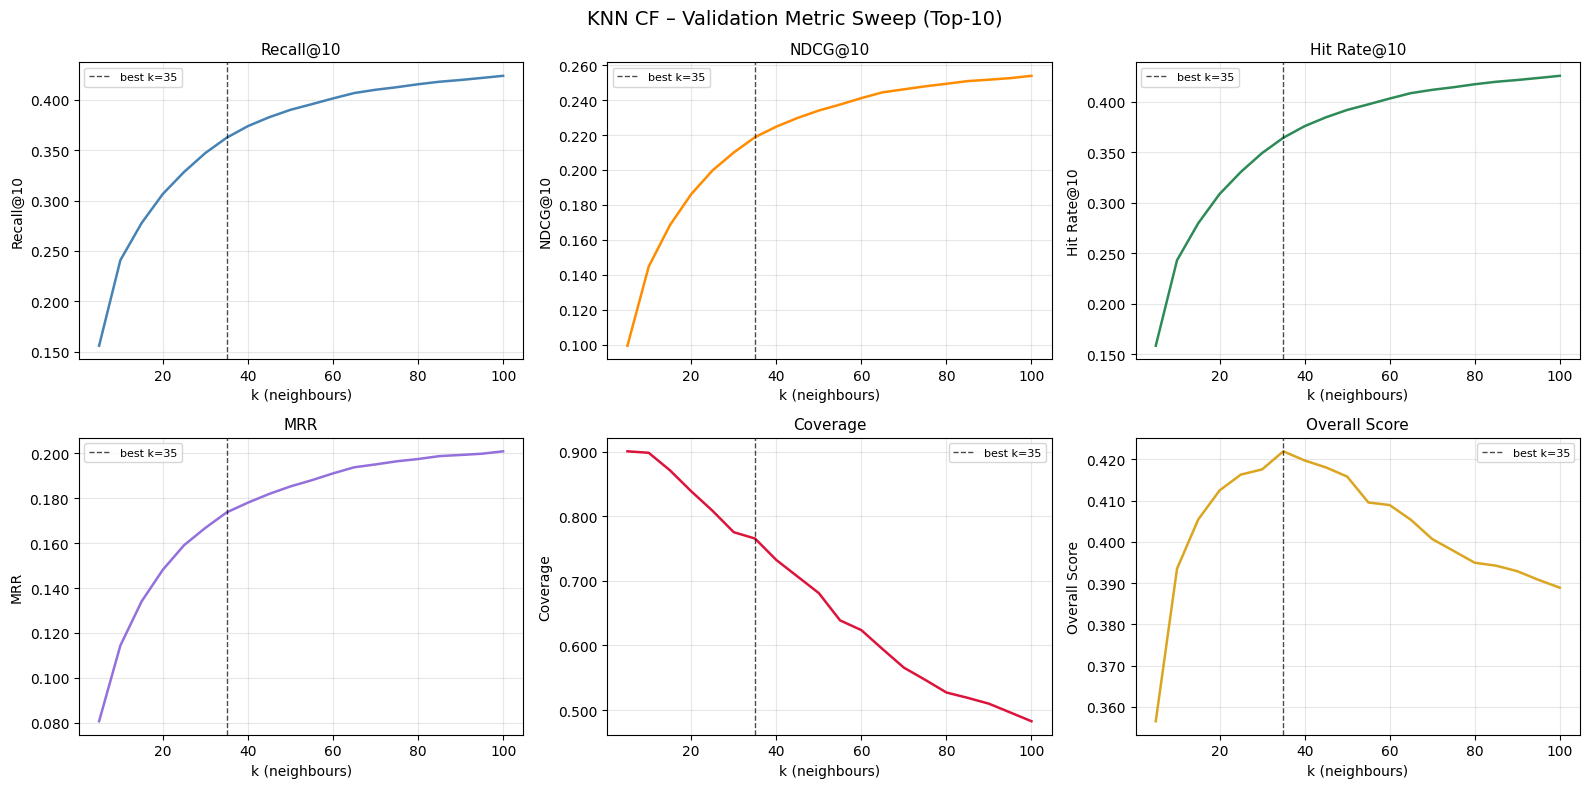

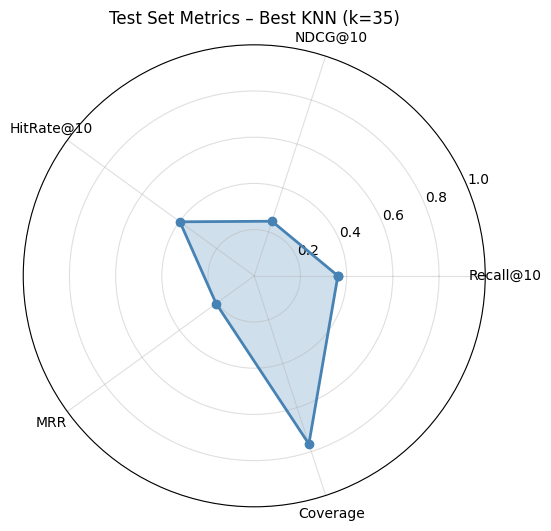

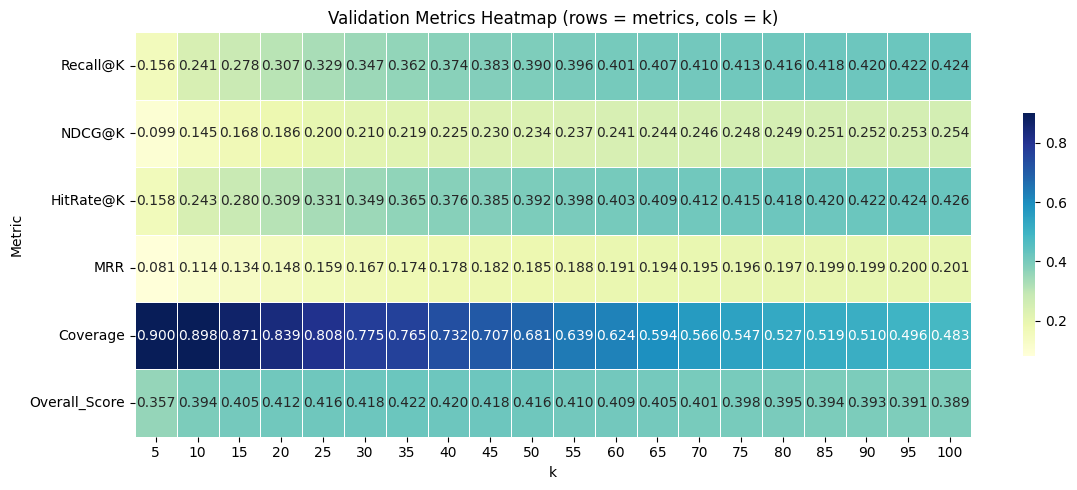

In [54]:
# 6 Visualisations

from IPython.display import display

# ── Fig 1: Metric sweep over k (validation set) ───────────────────────────────
metric_cfg = [
    ("Recall@K",      "Recall@10",     "steelblue"),
    ("NDCG@K",        "NDCG@10",       "darkorange"),
    ("HitRate@K",     "Hit Rate@10",   "seagreen"),
    ("MRR",           "MRR",           "mediumpurple"),
    ("Coverage",      "Coverage",      "crimson"),
    ("Overall_Score", "Overall Score", "goldenrod"),
]

fig1, axes1 = plt.subplots(2, 3, figsize=(16, 8))
fig1.suptitle(f"KNN CF – Validation Metric Sweep (Top-{TOP_N})", fontsize=14)
k_vals = val_results_df.index.values

for ax, (col, label, color) in zip(axes1.ravel(), metric_cfg):
    ax.plot(k_vals, val_results_df[col], color=color, linewidth=1.8)
    ax.axvline(best_k, color="black", linestyle="--", linewidth=1.0,
               alpha=0.7, label=f"best k={best_k}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("k (neighbours)")
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig1.tight_layout()
display(fig1)
plt.close(fig1)

# ── Fig 2: Radar chart for final TEST metrics ─────────────────────────────────
radar_keys   = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Coverage"]
radar_labels = ["Recall@10", "NDCG@10", "HitRate@10", "MRR", "Coverage"]
vals   = [test_metrics[m] for m in radar_keys]
angles = np.linspace(0, 2 * np.pi, len(radar_keys), endpoint=False).tolist()
vals   += vals[:1];  angles += angles[:1]

fig2, ax2 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax2.plot(angles, vals, "o-", linewidth=2, color="steelblue")
ax2.fill(angles, vals, alpha=0.25, color="steelblue")
ax2.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title(f"Test Set Metrics – Best KNN (k={best_k})", pad=15, fontsize=12)
ax2.grid(True, alpha=0.4)
display(fig2)
plt.close(fig2)

# ── Fig 3: Heatmap — val metrics per k ───────────────────────────────────────
hm_cols = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Coverage", "Overall_Score"]
fig3, ax3 = plt.subplots(figsize=(12, 5))
sns.heatmap(
    val_results_df[hm_cols].T,
    ax=ax3, cmap="YlGnBu", annot=True, fmt=".3f",
    linewidths=0.4, cbar_kws={"shrink": 0.6},
)
ax3.set_title("Validation Metrics Heatmap (rows = metrics, cols = k)", fontsize=12)
ax3.set_xlabel("k"); ax3.set_ylabel("Metric")
fig3.tight_layout()
display(fig3)
plt.close(fig3)

## 8. Save Results

Two artefacts are persisted to `data/processed/` so that the KG-enhanced and DL models can be benchmarked against the **exact same baseline** without re-running the sweep:

| File | Contents |
|---|---|
| `knn_cf_val_sweep_results.csv` | Full per-$k$ validation metrics — one row per $k \in \{5, 10, \dots, 100\}$, columns `Recall@K, NDCG@K, HitRate@K, MRR, Coverage, PopularityBias, Overall_Score`. |
| `knn_cf_final_test_summary.csv` | One-row final report: `best_k`, all six test-set metrics, `Overall_Score`, plus the dataset cardinalities $|U'|, |I'|, |\mathcal T|, |\mathcal V|, |\mathrm{Rel}|$. |

These files are the **single source of truth** for the baseline numbers reported in the project write-up.


In [55]:
## 8. Save Results

out_dir = ROOT / "data/processed"

val_results_df.to_csv(out_dir / "knn_cf_val_sweep_results.csv")
print(f"Validation sweep saved  : {out_dir / 'knn_cf_val_sweep_results.csv'}")

summary = {
    "best_k"              : best_k,
    "chosen_on"           : "validation",
    **{k: v for k, v in test_metrics.items()},
    "n_users"             : N_USERS,
    "n_songs"             : N_SONGS,
    "train_interactions"  : len(train_df),
    "val_interactions"    : len(val_df),
    "test_interactions"   : len(test_df),
}
pd.DataFrame([summary]).to_csv(out_dir / "knn_cf_final_test_summary.csv", index=False)
print(f"Final test summary saved: {out_dir / 'knn_cf_final_test_summary.csv'}")

Validation sweep saved  : ../data/processed/knn_cf_val_sweep_results.csv
Final test summary saved: ../data/processed/knn_cf_final_test_summary.csv


## 9. Qualitative Analysis Stub *(metadata-aware diagnostics)*

Numeric metrics like Recall@10 tell us **how often** a recommended song appears in the held-out set, but not **why** the others were rejected. A pop-rock track might be a perfectly sensible recommendation for a user whose history is 90 % pop-rock, even if it happens to miss the held-out positive. To capture this we will compare the **metadata distribution** (decade, artist, genre) of $\mathrm{Rec}_K(u)$ against $\mathcal{T}(u) \cup \mathrm{Rel}(u)$ — i.e. the user's actual taste profile.

The Lakh-MSD metadata file (`primary_genre`, `artist_name`, `year`) is currently **not fully cleaned** (year is missing for ~30 % of rows; genre tags need normalisation). Once that pre-processing is finished, the cell below — currently commented out — will produce three diagnostic figures per recommender:

1. **Decade overlap** — Jensen–Shannon divergence between the decade histograms of recommended vs. listened tracks.
2. **Artist concentration** — fraction of recommended tracks by artists already in the user's history.
3. **Genre Jaccard** — $|G_{\text{rec}} \cap G_{\text{listened}}| \,/\, |G_{\text{rec}} \cup G_{\text{listened}}|$ on the multiset of primary genres.

These are computed per user and then averaged across $U_\text{test}$.


In [56]:
# ─────────────────────────────────────────────────────────────────────────────
#  QUALITATIVE / METADATA-AWARE ANALYSIS  (commented out — needs cleaned metadata)
# ─────────────────────────────────────────────────────────────────────────────
#
# Pre-requisite: a cleaned metadata table indexed by `s_idx` with columns
#   ['artist_name', 'primary_genre', 'year']
# that you build once the LMD/MSD tag-cleaning notebook is finished.
#
# from collections import Counter
# from scipy.spatial.distance import jensenshannon
#
# # ── Load metadata and align to s_idx ─────────────────────────────────────────
# meta = (
#     lakh.drop_duplicates(subset="song_id")
#         .set_index("song_id")
#         .reindex([idx2song[i] for i in range(N_SONGS)])
#         .reset_index(drop=True)
# )
# meta["decade"] = (meta["year"] // 10 * 10).astype("Int64")  # 1990, 2000, …
#
#
# def decade_hist(s_idx_iterable):
#     decs = meta.loc[list(s_idx_iterable), "decade"].dropna().astype(int)
#     if decs.empty:
#         return None
#     all_decades = sorted(meta["decade"].dropna().unique())
#     counts = Counter(decs)
#     vec = np.array([counts.get(d, 0) for d in all_decades], dtype=float)
#     return vec / (vec.sum() + 1e-9), all_decades
#
#
# def artist_overlap(rec_idx, hist_idx):
#     hist_artists = set(meta.loc[list(hist_idx), "artist_name"].dropna())
#     rec_artists  = meta.loc[list(rec_idx),  "artist_name"].dropna()
#     if rec_artists.empty:
#         return 0.0
#     return float(rec_artists.isin(hist_artists).mean())
#
#
# def genre_jaccard(rec_idx, hist_idx):
#     g_rec  = set(meta.loc[list(rec_idx),  "primary_genre"].dropna())
#     g_hist = set(meta.loc[list(hist_idx), "primary_genre"].dropna())
#     if not (g_rec | g_hist):
#         return 0.0
#     return len(g_rec & g_hist) / len(g_rec | g_hist)
#
#
# # ── Aggregate diagnostics over the test users ────────────────────────────────
# rows = []
# for u_idx in test_user_indices:
#     rec  = test_recs[u_idx][:TOP_N]
#     hist = train_songs_per_user.get(u_idx, set()) | test_ground_truth.get(u_idx, set())
#     if not rec or not hist:
#         continue
#
#     # 1. Decade JS-divergence (lower = more similar to the user's taste)
#     dh_rec  = decade_hist(rec)
#     dh_hist = decade_hist(hist)
#     if dh_rec is not None and dh_hist is not None:
#         js = float(jensenshannon(dh_rec[0], dh_hist[0], base=2))
#     else:
#         js = np.nan
#
#     rows.append({
#         "u_idx"            : u_idx,
#         "decade_JSdiv"     : js,
#         "artist_overlap"   : artist_overlap(rec, hist),
#         "genre_jaccard"    : genre_jaccard(rec, hist),
#     })
#
# qual = pd.DataFrame(rows)
# print("Qualitative diagnostics (mean over test users)")
# print(qual.drop(columns="u_idx").mean().round(3).to_string())
#
# # Compare KNN vs MostPopular on the same diagnostics for a real apples-to-apples comparison
# # (recompute the rows above with `pop_recs` instead of `test_recs` and concat).
#
# # Optional: distribution plots
# # fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# # qual["decade_JSdiv"].hist(ax=ax[0], bins=20); ax[0].set_title("Decade JS-divergence")
# # qual["artist_overlap"].hist(ax=ax[1], bins=20); ax[1].set_title("Artist overlap (train ∪ test)")
# # qual["genre_jaccard"].hist(ax=ax[2], bins=20); ax[2].set_title("Genre Jaccard")
# # plt.tight_layout(); plt.show()
